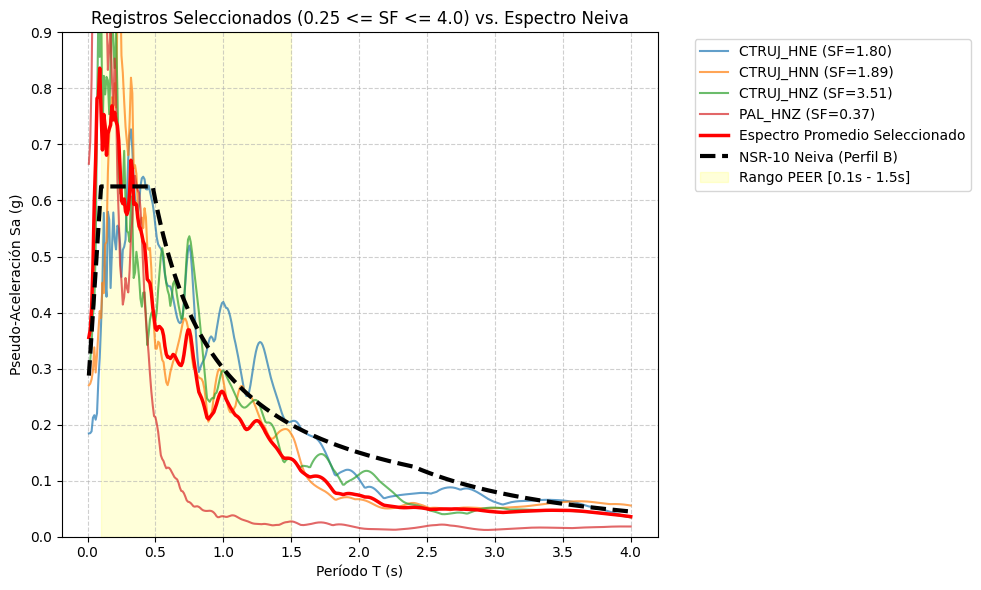


REPORTE FINAL DE SELECCIÓN DE REGISTROS
Estacion Canal  PGA_Original_g  Factor_Escala_SF  PGA_Escalado_g       Estado
     URE   HNE        0.012942            16.578           0.215   DESCARTADO
     URE   HNN        0.011417            17.763           0.203   DESCARTADO
     URE   HNZ        0.004547            60.969           0.277   DESCARTADO
   CTRUJ   HNE        0.102373             1.800           0.184 SELECCIONADO
   CTRUJ   HNN        0.142585             1.890           0.269 SELECCIONADO
   CTRUJ   HNZ        0.085561             3.508           0.300 SELECCIONADO
     PAL   HNE        2.024735             0.236           0.477   DESCARTADO
     PAL   HNN        2.214693             0.193           0.427   DESCARTADO
     PAL   HNZ        1.753718             0.372           0.653 SELECCIONADO


In [2]:
import os
import obspy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# 1. CONFIGURACIÓN DE RUTAS Y PARÁMETROS DE FILTRADO
# =============================================================================
ruta_mseed = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos originales\SGCWaveForm.mseed"
dir_salida = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos sismo"

os.makedirs(dir_salida, exist_ok=True)

# Estaciones candidatas en roca (Perfil B)
estaciones_roca = ["CTRUJ", "PAL", "URE", "RUS", "POP", "ROSC"]

# Parámetros de optimización y criterio de selección PEER
T_MIN_PEER, T_MAX_PEER = 0.1, 1.5
SF_MIN, SF_MAX = 0.25, 4.0  # Criterio de exclusión: solo se aceptan 0.25 <= SF <= 4.0

# =============================================================================
# 2. FUNCIONES TÉCNICAS
# =============================================================================
def normalizar_aceleracion_a_g(tr):
    """Convierte amplitudes a unidades de g según la magnitud de la señal."""
    datos = tr.data.astype(float)
    pga_raw = np.max(np.abs(datos))

    if pga_raw > 1000.0:        # Cuentas digitales (counts)
        acc_g = (datos / 400000.0) / 9.81
    elif pga_raw > 20.0:         # Gal (cm/s^2)
        acc_g = (datos / 100.0) / 9.81
    elif pga_raw > 1.5:          # m/s^2
        acc_g = datos / 9.81
    else:                        # Ya en g
        acc_g = datos

    return acc_g


def espectro_nsr10_neiva_roca(periodos, I=1.0):
    """Genera el espectro objetivo de la NSR-10 para Neiva (Perfil B)."""
    Aa, Av = 0.25, 0.25
    Fa, Fv = 1.0, 1.0

    T0 = 0.1 * (Av * Fv) / (Aa * Fa)  # 0.10 s
    TC = 0.48 * (Av * Fv) / (Aa * Fa) # 0.48 s
    TL = 2.4 * Fv                     # 2.40 s

    Sa_norma = np.zeros(len(periodos))
    for idx, T in enumerate(periodos):
        if T < T0:
            Sa_norma[idx] = Aa * Fa * I * (1.0 + 1.5 * (T / T0))
        elif T0 <= T <= TC:
            Sa_norma[idx] = 2.5 * Aa * Fa * I
        elif TC < T <= TL:
            Sa_norma[idx] = (1.2 * Av * Fv * I) / T
        else:
            Sa_norma[idx] = (1.2 * Av * Fv * TL * I) / (T**2)

    return Sa_norma


def calcular_espectro_newmark(acc_g, dt, periodos, damping=0.05):
    """Calcula la pseudo-aceleración Sa (g) mediante integración Newmark-Beta."""
    acc_m_s2 = acc_g * 9.81
    Sa_g = np.zeros(len(periodos))
    gamma, beta = 0.5, 0.25
    N = len(acc_m_s2)

    for idx, T in enumerate(periodos):
        if T <= 0:
            Sa_g[idx] = np.max(np.abs(acc_g))
            continue
            
        omega = 2.0 * np.pi / T
        m = 1.0
        c = 2.0 * damping * omega * m
        k = (omega ** 2) * m

        k_hat = k + (gamma / (beta * dt)) * c + (1.0 / (beta * dt**2)) * m
        a_const = (1.0 / (beta * dt)) * m + (gamma / beta) * c
        b_const = (1.0 / (2.0 * beta)) * m + dt * ((gamma / (2.0 * beta)) - 1.0) * c

        u, v, a_rel = np.zeros(N), np.zeros(N), np.zeros(N)
        a_rel[0] = -acc_m_s2[0]

        for i in range(N - 1):
            df = -m * (acc_m_s2[i+1] - acc_m_s2[i]) + a_const * v[i] + b_const * a_rel[i]
            du = df / k_hat
            dv = (gamma / (beta * dt)) * du - (gamma / beta) * v[i] + dt * (1.0 - gamma / (2.0 * beta)) * a_rel[i]
            da = (1.0 / (beta * dt**2)) * du - (1.0 / (beta * dt)) * v[i] - (1.0 / (2.0 * beta)) * a_rel[i]

            u[i+1] = u[i] + du
            v[i+1] = v[i] + dv
            a_rel[i+1] = a_rel[i] + da

        Sa_m_s2 = (omega ** 2) * np.max(np.abs(u))
        Sa_g[idx] = Sa_m_s2 / 9.81

    return Sa_g


def calcular_factor_escala_peer(Sa_real, Sa_objetivo, periodos, T_min, T_max):
    """Mínimos cuadrados para ajustar el espectro en [T_min, T_max]."""
    mask = (periodos >= T_min) & (periodos <= T_max)
    Sa_r = Sa_real[mask]
    Sa_o = Sa_objetivo[mask]
    return np.sum(Sa_o * Sa_r) / np.sum(Sa_r**2)


# =============================================================================
# 3. FILTRADO Y PROCESAMIENTO SELECCIONADO
# =============================================================================
st = obspy.read(ruta_mseed)
st_roca = obspy.Stream([tr for tr in st if tr.stats.station in estaciones_roca and tr.stats.channel.startswith("HN")])

periodos = np.linspace(0.01, 4.0, 400)
Sa_target = espectro_nsr10_neiva_roca(periodos)

resumen_proceso = []
espectros_seleccionados = []

fig_global, ax_global = plt.subplots(figsize=(10, 6))

for tr in st_roca:
    estacion, canal = tr.stats.station, tr.stats.channel
    id_traza = f"{estacion}_{canal}"

    # Acondicionamiento de señal
    tr_proc = tr.copy()
    tr_proc.detrend("linear")
    tr_proc.filter("bandpass", freqmin=0.1, freqmax=25.0, corners=4, zerophase=True)

    dt = tr_proc.stats.delta
    acc_g_orig = normalizar_aceleracion_a_g(tr_proc)
    tiempo = np.arange(len(acc_g_orig)) * dt

    # Cálculo espectral y SF
    Sa_real = calcular_espectro_newmark(acc_g_orig, dt, periodos)
    SF = calcular_factor_escala_peer(Sa_real, Sa_target, periodos, T_MIN_PEER, T_MAX_PEER)

    # Evaluación de criterio de aceptación
    aceptado = (SF_MIN <= SF <= SF_MAX)
    estado_str = "SELECCIONADO" if aceptado else "DESCARTADO"

    resumen_proceso.append({
        "Estacion": estacion,
        "Canal": canal,
        "PGA_Original_g": np.max(np.abs(acc_g_orig)),
        "Factor_Escala_SF": round(SF, 3),
        "PGA_Escalado_g": round(np.max(np.abs(acc_g_orig * SF)), 3),
        "Estado": estado_str
    })

    if aceptado:
        acc_g_escalada = acc_g_orig * SF
        Sa_escalado = Sa_real * SF
        espectros_seleccionados.append(Sa_escalado)

        # Exportar CSV de acelerograma y espectro válidos
        pd.DataFrame({"Tiempo_s": tiempo, "Acc_Escalada_g": acc_g_escalada}).to_csv(
            os.path.join(dir_salida, f"Acelerograma_Seleccionado_{id_traza}.csv"), index=False
        )
        pd.DataFrame({"Periodo_s": periodos, "Sa_Escalado_g": Sa_escalado, "Sa_Target_g": Sa_target}).to_csv(
            os.path.join(dir_salida, f"Espectro_Seleccionado_{id_traza}.csv"), index=False
        )

        # Añadir al gráfico global
        ax_global.plot(periodos, Sa_escalado, alpha=0.7, lw=1.5, label=f"{id_traza} (SF={SF:.2f})")

# Graficar promedio de la serie seleccionada si existen registros válidos
if len(espectros_seleccionados) > 0:
    Sa_promedio = np.mean(espectros_seleccionados, axis=0)
    ax_global.plot(periodos, Sa_promedio, color="red", lw=2.5, label="Espectro Promedio Seleccionado")

# Superponer espectro objetivo NSR-10 y franja de optimización
ax_global.plot(periodos, Sa_target, color="black", lw=3.0, linestyle="--", label="NSR-10 Neiva (Perfil B)")
ax_global.axvspan(T_MIN_PEER, T_MAX_PEER, color='yellow', alpha=0.15, label=f"Rango PEER [{T_MIN_PEER}s - {T_MAX_PEER}s]")

ax_global.set_title("Registros Seleccionados (0.25 <= SF <= 4.0) vs. Espectro Neiva")
ax_global.set_xlabel("Período T (s)")
ax_global.set_ylabel("Pseudo-Aceleración Sa (g)")
ax_global.set_ylim(0, 0.9)
ax_global.grid(True, linestyle="--", alpha=0.6)
ax_global.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Guardar gráfica y reporte de selección
plt.savefig(os.path.join(dir_salida, "Comparacion_Registros_Seleccionados.png"), dpi=300)
plt.show()

df_reporte = pd.DataFrame(resumen_proceso)
df_reporte.to_csv(os.path.join(dir_salida, "Reporte_Seleccion_PEER.csv"), index=False)

print("\n" + "="*80)
print("REPORTE FINAL DE SELECCIÓN DE REGISTROS")
print("="*80)
print(df_reporte.to_string(index=False))

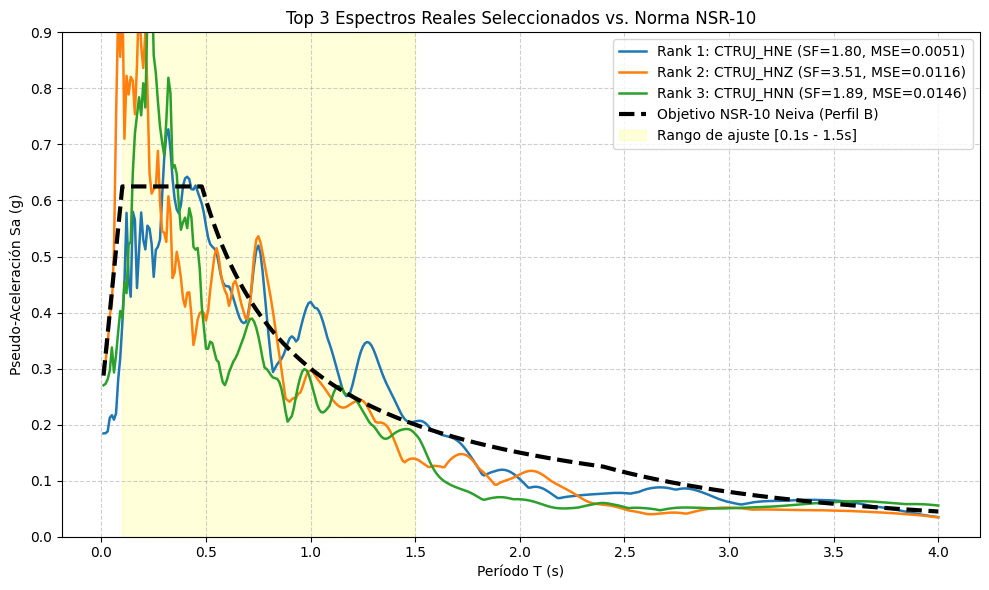


SELECCIÓN DE LOS 3 MEJORES REGISTROS REALES INDIVIDUALES
 Ranking ID_Registro  Factor_Escala_SF  Error_MSE  PGA_Final_g              Archivo_Guardado
       1   CTRUJ_HNE             1.800    0.00506        0.184 SismoReal_Rank1_CTRUJ_HNE.csv
       2   CTRUJ_HNZ             3.508    0.01155        0.300 SismoReal_Rank2_CTRUJ_HNZ.csv
       3   CTRUJ_HNN             1.890    0.01463        0.269 SismoReal_Rank3_CTRUJ_HNN.csv


In [4]:
import os
import obspy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# 1. CONFIGURACIÓN Y CRITERIOS DE SELECCIÓN INDIVIDUAL
# =============================================================================
ruta_mseed = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos originales\SGCWaveForm.mseed"
dir_salida = r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos sismo\sismos_seleccionados"

os.makedirs(dir_salida, exist_ok=True)

# Estaciones candidatas en roca
estaciones_roca = ["CTRUJ", "PAL", "URE", "RUS", "POP", "ROSC"]

# Rango de períodos de interés para la estructura / suelo
T_MIN_PEER, T_MAX_PEER = 0.1, 1.5

# Límites permitidos para el Factor de Escala (SF)
SF_MIN, SF_MAX = 0.25, 4.0

# Número de sismos reales individuales a seleccionar (p. ej., los 3 mejores)
NUM_SISMOS_A_SELECCIONAR = 3

# =============================================================================
# 2. FUNCIONES MATEMÁTICAS Y ESPECTRALES
# =============================================================================
def normalizar_aceleracion_a_g(tr):
    """Convierte amplitudes a unidades de 'g'."""
    datos = tr.data.astype(float)
    pga_raw = np.max(np.abs(datos))

    if pga_raw > 1000.0:
        acc_g = (datos / 400000.0) / 9.81
    elif pga_raw > 20.0:
        acc_g = (datos / 100.0) / 9.81
    elif pga_raw > 1.5:
        acc_g = datos / 9.81
    else:
        acc_g = datos

    return acc_g


def espectro_nsr10_neiva_roca(periodos, I=1.0):
    """Espectro elástico de diseño NSR-10 Neiva (Perfil B)."""
    Aa, Av = 0.25, 0.25
    Fa, Fv = 1.0, 1.0

    T0 = 0.1 * (Av * Fv) / (Aa * Fa)
    TC = 0.48 * (Av * Fv) / (Aa * Fa)
    TL = 2.4 * Fv

    Sa_norma = np.zeros(len(periodos))
    for idx, T in enumerate(periodos):
        if T < T0:
            Sa_norma[idx] = Aa * Fa * I * (1.0 + 1.5 * (T / T0))
        elif T0 <= T <= TC:
            Sa_norma[idx] = 2.5 * Aa * Fa * I
        elif TC < T <= TL:
            Sa_norma[idx] = (1.2 * Av * Fv * I) / T
        else:
            Sa_norma[idx] = (1.2 * Av * Fv * TL * I) / (T**2)

    return Sa_norma


def calcular_espectro_newmark(acc_g, dt, periodos, damping=0.05):
    """Integración de Newmark-Beta para obtener el espectro de respuestas Sa (g)."""
    acc_m_s2 = acc_g * 9.81
    Sa_g = np.zeros(len(periodos))
    gamma, beta = 0.5, 0.25
    N = len(acc_m_s2)

    for idx, T in enumerate(periodos):
        if T <= 0:
            Sa_g[idx] = np.max(np.abs(acc_g))
            continue
            
        omega = 2.0 * np.pi / T
        m = 1.0
        c = 2.0 * damping * omega * m
        k = (omega ** 2) * m

        k_hat = k + (gamma / (beta * dt)) * c + (1.0 / (beta * dt**2)) * m
        a_const = (1.0 / (beta * dt)) * m + (gamma / beta) * c
        b_const = (1.0 / (2.0 * beta)) * m + dt * ((gamma / (2.0 * beta)) - 1.0) * c

        u, v, a_rel = np.zeros(N), np.zeros(N), np.zeros(N)
        a_rel[0] = -acc_m_s2[0]

        for i in range(N - 1):
            df = -m * (acc_m_s2[i+1] - acc_m_s2[i]) + a_const * v[i] + b_const * a_rel[i]
            du = df / k_hat
            dv = (gamma / (beta * dt)) * du - (gamma / beta) * v[i] + dt * (1.0 - gamma / (2.0 * beta)) * a_rel[i]
            da = (1.0 / (beta * dt**2)) * du - (1.0 / (beta * dt)) * v[i] - (1.0 / (2.0 * beta)) * a_rel[i]

            u[i+1] = u[i] + du
            v[i+1] = v[i] + dv
            a_rel[i+1] = a_rel[i] + da

        Sa_m_s2 = (omega ** 2) * np.max(np.abs(u))
        Sa_g[idx] = Sa_m_s2 / 9.81

    return Sa_g


def calcular_mse_y_sf(Sa_real, Sa_objetivo, periodos, T_min, T_max):
    """Calcula el factor de escala óptimo SF y el Error Cuadrático Medio (MSE)."""
    mask = (periodos >= T_min) & (periodos <= T_max)
    Sa_r = Sa_real[mask]
    Sa_o = Sa_objetivo[mask]

    # Factor de escala por mínimos cuadrados
    SF = np.sum(Sa_o * Sa_r) / np.sum(Sa_r**2)
    
    # Espectro ajustado individual
    Sa_escalado = Sa_real * SF

    # Error cuadrático medio respecto a la norma
    mse = np.mean((Sa_escalado[mask] - Sa_o)**2)

    return SF, mse

# =============================================================================
# 3. EVALUACIÓN Y RANKING DE REGISTROS REALES
# =============================================================================
st = obspy.read(ruta_mseed)
st_roca = obspy.Stream([tr for tr in st if tr.stats.station in estaciones_roca and tr.stats.channel.startswith("HN")])

periodos = np.linspace(0.01, 4.0, 400)
Sa_target = espectro_nsr10_neiva_roca(periodos)

registros_evaluados = []

for tr in st_roca:
    estacion, canal = tr.stats.station, tr.stats.channel
    id_traza = f"{estacion}_{canal}"

    # Acondicionamiento de señal
    tr_proc = tr.copy()
    tr_proc.detrend("linear")
    tr_proc.filter("bandpass", freqmin=0.1, freqmax=25.0, corners=4, zerophase=True)

    dt = tr_proc.stats.delta
    acc_g_orig = normalizar_aceleracion_a_g(tr_proc)
    tiempo = np.arange(len(acc_g_orig)) * dt

    # Espectro real sin escalar
    Sa_real = calcular_espectro_newmark(acc_g_orig, dt, periodos)

    # Evaluación de ajuste (SF y MSE)
    SF, mse = calcular_mse_y_sf(Sa_real, Sa_target, periodos, T_MIN_PEER, T_MAX_PEER)

    # Filtrar solo registros con factor de escala razonable
    if SF_MIN <= SF <= SF_MAX:
        registros_evaluados.append({
            "id_traza": id_traza,
            "estacion": estacion,
            "canal": canal,
            "dt": dt,
            "tiempo": tiempo,
            "acc_g_orig": acc_g_orig,
            "acc_g_escalada": acc_g_orig * SF,
            "Sa_escalado": Sa_real * SF,
            "SF": SF,
            "MSE": mse,
            "PGA_escalado_g": np.max(np.abs(acc_g_orig * SF))
        })

# Ordenar por menor error MSE (ranking de mejor ajuste a peor)
registros_evaluados = sorted(registros_evaluados, key=lambda x: x["MSE"])

# Seleccionar los top N sismos reales
sismos_seleccionados = registros_evaluados[:NUM_SISMOS_A_SELECCIONAR]

# =============================================================================
# 4. EXPORTACIÓN Y GRAFICACIÓN DE LOS SISMOS SELECCIONADOS
# =============================================================================
plt.figure(figsize=(10, 6))
resumen_exportacion = []

for idx, sismo in enumerate(sismos_seleccionados, 1):
    id_traza = sismo["id_traza"]
    
    # 1. Exportar el Acelerograma Real Escalado individual (formato ejecutable para software geotécnico)
    df_acelerograma = pd.DataFrame({
        "Tiempo_s": sismo["tiempo"],
        "Aceleracion_g": sismo["acc_g_escalada"]
    })
    archivo_acc = os.path.join(dir_salida, f"SismoReal_Rank{idx}_{id_traza}.csv")
    df_acelerograma.to_csv(archivo_acc, index=False)

    # 2. Graficar espectro real individual
    plt.plot(periodos, sismo["Sa_escalado"], lw=1.8, 
             label=f"Rank {idx}: {id_traza} (SF={sismo['SF']:.2f}, MSE={sismo['MSE']:.4f})")

    resumen_exportacion.append({
        "Ranking": idx,
        "ID_Registro": id_traza,
        "Factor_Escala_SF": round(sismo["SF"], 3),
        "Error_MSE": round(sismo["MSE"], 5),
        "PGA_Final_g": round(sismo["PGA_escalado_g"], 3),
        "Archivo_Guardado": os.path.basename(archivo_acc)
    })

# Superponer espectro de norma NSR-10 Neiva
plt.plot(periodos, Sa_target, color="black", lw=3.0, linestyle="--", label="Objetivo NSR-10 Neiva (Perfil B)")
plt.axvspan(T_MIN_PEER, T_MAX_PEER, color='yellow', alpha=0.15, label=f"Rango de ajuste [{T_MIN_PEER}s - {T_MAX_PEER}s]")

plt.title(f"Top {NUM_SISMOS_A_SELECCIONAR} Espectros Reales Seleccionados vs. Norma NSR-10")
plt.xlabel("Período T (s)")
plt.ylabel("Pseudo-Aceleración Sa (g)")
plt.ylim(0, 0.9)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

plt.savefig(os.path.join(dir_salida, "Top_Sismos_Reales_Seleccionados.png"), dpi=300)
plt.show()

# Reporte final por pantalla
df_reporte = pd.DataFrame(resumen_exportacion)
df_reporte.to_csv(os.path.join(dir_salida, "Reporte_Sismos_Seleccionados.csv"), index=False)

print("\n" + "="*85)
print(f"SELECCIÓN DE LOS {NUM_SISMOS_A_SELECCIONAR} MEJORES REGISTROS REALES INDIVIDUALES")
print("="*85)
print(df_reporte.to_string(index=False))

In [3]:
import obspy

# Cargar y ver resumen general del archivo
st = obspy.read(r"C:\Proyectos_de_codigo\Universidad\Sismo\Sismo-geotecnia\datos\datos originales\SGCWaveForm.mseed")
print(st)  # Muestra lista de trazas/estaciones presentes

# Inspeccionar metadatos de la primera traza
print(st[0].stats)

# Graficar rápidamente todas las trazas en pantalla
st.plot()

282 Trace(s) in Stream:

CM.URE.10.HNE | 2026-08-10T12:32:57.419538Z - 2026-08-10T12:39:00.649538Z | 200.0 Hz, 72647 samples
...
(280 other traces)
...
CM.SCLC.10.HNZ | 2026-08-10T12:32:59.455000Z - 2026-08-10T12:39:00.960000Z | 200.0 Hz, 72302 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]
         network: CM
         station: URE
        location: 10
         channel: HNE
       starttime: 2026-08-10T12:32:57.419538Z
         endtime: 2026-08-10T12:39:00.649538Z
   sampling_rate: 200.0
           delta: 0.005
            npts: 72647
           calib: 1.0
         _format: MSEED
           mseed: AttribDict({'dataquality': 'D', 'number_of_records': 210, 'encoding': 'STEIM2', 'byteorder': '>', 'record_length': 512, 'filesize': 1048576})
